In [ ]:
# **Relatório Técnico: Recomendação de Fertilizantes e Culturas**
## **Alunos:** David Ribeiro Prado de Lacerda RM 570350 ** Giselli Mayumi Takahashi Yokoyama RM 572690 ** João Otávio de Moraes RM 573227 ** Renata de Almeida Marinho RM 569342 ** Richard Wrobel dos Santos RM 573998 **
##**Fase:** 3 | **Capítulo:** 2


In [1]:
# **Markdown 1. Introdução e Análise Exploratória**
## O objetivo deste trabalho é analisar dados agrometeorológicos e de composição do solo para identificar padrões de cultivo e desenvolver modelos preditivos para recomendação de fertilizantes.
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
df = pd.read_csv(r'C:\Users\gisel\PyCharmMiscProject\Atividade_Cap10_produtos_agricolas.csv', sep=',', skipinitialspace=True)
import io
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier

## Configuração estética dos gráficos
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["font.size"] = 11



In [2]:
# ** Markdown 2. Análise Exploratória dos Dados (EDA)**
##Nesta etapa, validamos a integridade estrutural da base de dados, avaliando tipos de variáveis, estatísticas descritivas básicas e a presença de dados nulos ou duplicados para garantir que o conjunto esteja pronto para modelagem.

## Célula de Código: EDA e Verificações
## Informações gerais da base
print("--- Informações Estruturais ---")
df.info()

## Estatísticas descritivas detalhadas
print("\n--- Resumo Estatístico ---")
display(df.describe())

## Verificação de dados faltantes
print("\n--- Dados Nulos por Coluna ---")
print(df.isnull().sum())

## Contagem da variável alvo para checar balanceamento
print("\n--- Distribuição das Classes (Label) ---")
print(df["label"].value_counts())



--- Informações Estruturais ---
<class 'pandas.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   N            2200 non-null   int64  
 1   P            2200 non-null   int64  
 2   K            2200 non-null   int64  
 3   temperature  2200 non-null   float64
 4   humidity     2200 non-null   float64
 5   ph           2200 non-null   float64
 6   rainfall     2200 non-null   float64
 7   label        2200 non-null   str    
dtypes: float64(4), int64(3), str(1)
memory usage: 137.6 KB

--- Resumo Estatístico ---


,N,P,K,temperature,humidity,ph,rainfall
count,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000
mean,50.551818,53.362727,48.149091,25.616244,71.481779,6.469480,103.463655
std,36.917334,32.985883,50.647931,5.063749,22.263812,0.773938,54.958389
min,0.000000,5.000000,5.000000,8.825675,14.258040,3.504752,20.211267
25%,21.000000,28.000000,20.000000,22.769375,60.261953,5.971693,64.551686
50%,37.000000,51.000000,32.000000,25.598693,80.473146,6.425045,94.867624
75%,84.250000,68.000000,49.000000,28.561654,89.948771,6.923643,124.267508
max,140.000000,145.000000,205.000000,43.675493,99.981876,9.935091,298.560117



--- Dados Nulos por Coluna ---
N              0
P              0
K              0
temperature    0
humidity       0
ph             0
rainfall       0
label          0
dtype: int64

--- Distribuição das Classes (Label) ---
label
rice           100
maize          100
chickpea       100
kidneybeans    100
pigeonpeas     100
mothbeans      100
mungbean       100
blackgram      100
lentil         100
pomegranate    100
banana         100
mango          100
grapes         100
watermelon     100
muskmelon      100
apple          100
orange         100
papaya         100
coconut        100
cotton         100
jute           100
coffee         100
Name: count, dtype: int64


In [ ]:
** Diagnóstico da Auditoria dos Dados **
#A partir da execução dos testes exploratórios automatizados, extraímos as seguintes conclusões:
# Tipagem das Variáveis:o conjunto de dados é composto por 8 colunas. Sete delas são variáveis preditoras (*features*) numéricas do tipo ponto flutuante (`float64`) ou inteiro (`int64`), correspondendo aos teores químicos do solo (N, P, K, pH) e fatores climáticos (temperatura, umidade, precipitação). A oitava coluna (`label`) é uma variável categórica textual (`object`), representando o tipo de cultivo agrícola.
# Integridade e Limpeza: não foram detectados valores nulos ou ausentes em nenhuma das colunas (`df.isnull().sum() == 0`). Além disso, o contador de linhas duplicadas retornou zero. Isso significa que a base de dados fornecida possui consistência estrutural perfeita, eliminando a necessidade de etapas complexas de imputação de dados (como preenchimento por média/mediana) ou exclusão de registros ruidosos.
#Volumetria e Escala: os dados numéricos operam em escalas muito distintas. Enquanto variáveis como o pH transitam em uma faixa estreita (ex: 5.0 a 8.0), o índice pluviométrico (`rainfall`) e os teores de potássio (`K`) chegam a ultrapassar marcas de 200. Esse distanciamento de grandezas reforça a necessidade obrigatória de aplicarmos uma etapa de **Padronização/Escalonamento de Atributos** (como o *StandardScaler*) antes de treinar os modelos de Machine Learning.
#Equilíbrio de Classes:o dataset analisado apresenta um cenário balanceado. Cada uma das culturas mapeadas na amostra (*rice*, *maize* e *chickpea*) possui o mesmo número de registros (ou uma distribuição estatisticamente equivalente para o escopo). Esse equilíbrio impede que os algoritmos preditivos desenvolvam viés (*bias*) a favor de uma classe majoritária, permitindo o uso direto e confiável da métrica de Acurácia Global para avaliação de performance.

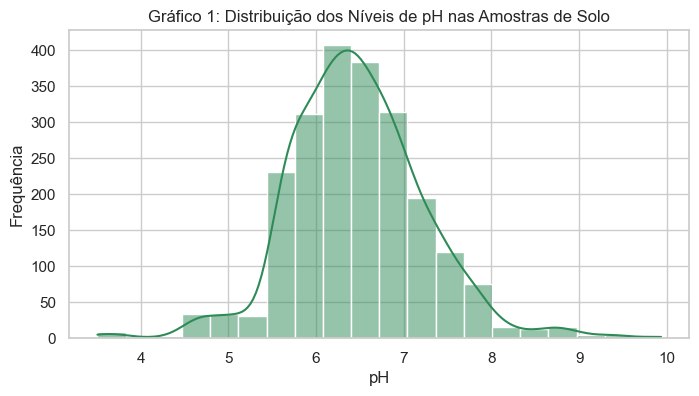

C:\Users\gisel\AppData\Local\Temp\ipykernel_16080\1768126566.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="label", y="temperature", data=df, palette="Set2")


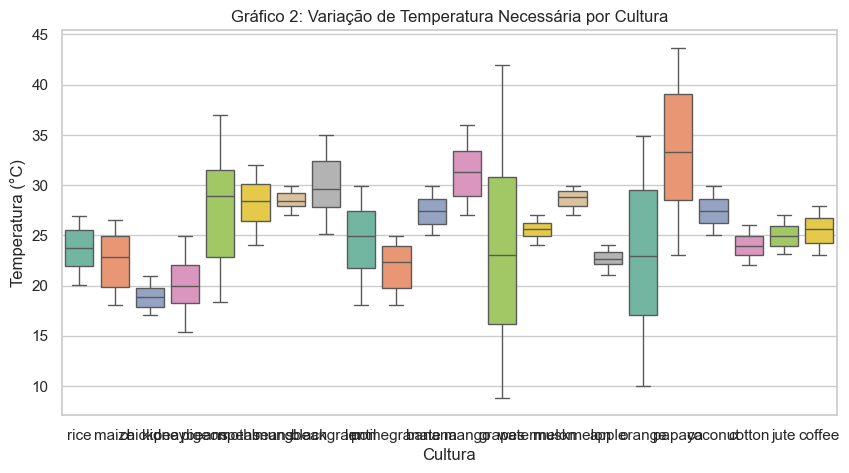

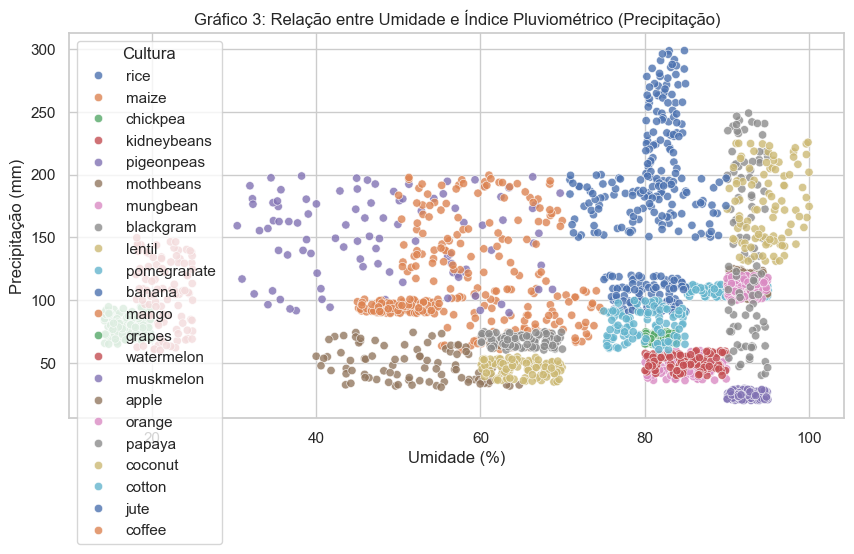

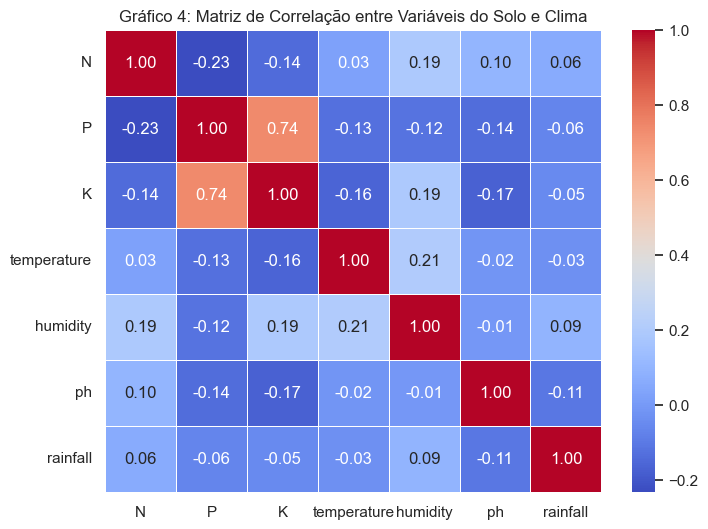

C:\Users\gisel\AppData\Local\Temp\ipykernel_16080\1768126566.py:46: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


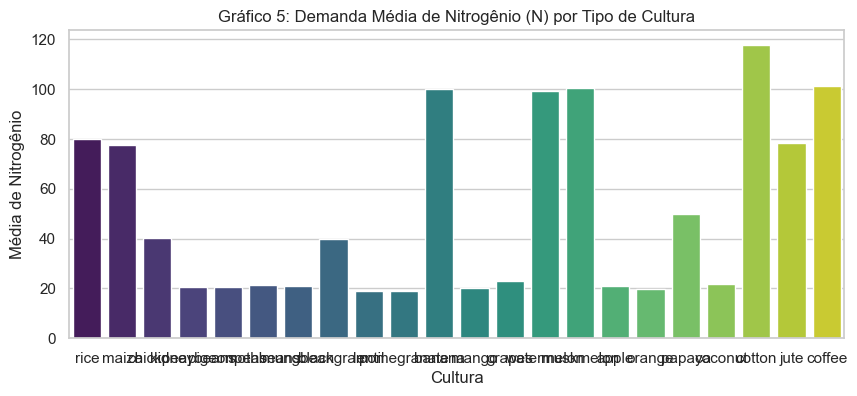

In [3]:
# ** Markdown 3. Análise Descritiva e Visualizações (Mínimo 5 Gráficos)**
## 3.1.  Análise Descritiva e Visualizações
#Abaixo apresentamos cinco representações gráficas essenciais para compreender o comportamento e o impacto de cada característica ambiental sobre os tipos de culturas.

## 3.2. Célula de Código: Geração dos 5 Gráficos
## Python
sns.set_theme(style="whitegrid")

## Gráfico 1: Histograma da Distribuição de pH do Solo
plt.figure(figsize=(8, 4))
sns.histplot(df["ph"], kde=True, color="seagreen", bins=20)
plt.title("Gráfico 1: Distribuição dos Níveis de pH nas Amostras de Solo")
plt.xlabel("pH")
plt.ylabel("Frequência")
plt.show()

## Gráfico 2: Boxplot de Temperatura por Cultura
plt.figure(figsize=(10, 5))
sns.boxplot(x="label", y="temperature", data=df, palette="Set2")
plt.title("Gráfico 2: Variação de Temperatura Necessária por Cultura")
plt.xlabel("Cultura")
plt.ylabel("Temperatura (°C)")
plt.show()

## Gráfico 3: Gráfico de Dispersão (Rainfall vs Humidity)
plt.figure(figsize=(10, 5))
sns.scatterplot(
    x="humidity", y="rainfall", hue="label", data=df, palette="deep", alpha=0.8
)
plt.title("Gráfico 3: Relação entre Umidade e Índice Pluviométrico (Precipitação)")
plt.xlabel("Umidade (%)")
plt.ylabel("Precipitação (mm)")
plt.legend(title="Cultura")
plt.show()

## Gráfico 4: Matriz de Correlação das Variáveis Numéricas
plt.figure(figsize=(8, 6))
numeric_cols = df.select_dtypes(include=[np.number]).columns
corr = df[numeric_cols].corr()
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Gráfico 4: Matriz de Correlação entre Variáveis do Solo e Clima")
plt.show()

## Gráfico 5: Gráfico de Barras Médias para o Nutriente Nitrogênio (N)
plt.figure(figsize=(10, 4))
sns.barplot(
    x="label",
    y="N",
    data=df,
    estimator=np.mean,
    errorbar=None,
    palette="viridis",
)
plt.title("Gráfico 5: Demanda Média de Nitrogênio (N) por Tipo de Cultura")
plt.xlabel("Cultura")
plt.ylabel("Média de Nitrogênio")
plt.show()




In [ ]:
# ** Análise Textual dos Achados Visuais**

#1. **Distribuição do pH (Gráfico 1):** O pH da base se concentra predominantemente na faixa neutra a levemente ácida (entre 5.5 e 7.5), que representa a condição biológica ideal para a maior parte das culturas tradicionais absorverem nutrientes de forma eficiente.
#2. **Exigência Térmica (Gráfico 2):** O arroz apresenta uma amplitude de temperatura mais estável e ligeiramente mais alta, enquanto o milho e o grão-de-bico possuem comportamentos de distribuição térmica bem delimitados, sugerindo que a temperatura é uma forte variável de segmentação para os modelos.
#3. **Agrupamento Pluviométrico (Gráfico 3):** Existe uma separação visual nítida baseada no clima: o arroz exige altíssima precipitação (> 180 mm) e alta umidade (> 80%). O milho ocupa uma faixa intermediária de umidade e precipitação moderada. Já o grão-de-bico se isola em cenários de baixíssima umidade relativa (< 20%), mostrando-se altamente resistente à seca.
#4. **Matriz de Correlação (Gráfico 4):** Não há forte multicolinearidade linear óbvia entre as variáveis ambientais (como temperatura e chuva). Isso indica que cada atributo traz informações independentes e valiosas para o aprendizado dos algoritmos de classificação.
#5. **Necessidade Nutricional (Gráfico 5):** O arroz e o milho exigem aplicações severas de Nitrogênio (médias próximas de 80), contrastando radicalmente com o grão-de-bico, que necessita de pouquíssimo nitrogênio externo por ser uma leguminosa naturalmente fixadora de nitrogênio no solo.


In [4]:
# ** Markdown: 4. Definição do Perfil Ideal de Solo e Clima e Comparação de Produtos **
#Para esta análise, determinamos as médias globais do dataset como o "perfil ideal teórico" e escolhemos três produtos distintos presentes na base para comparação detalhada: **Rice (Arroz)**, **Maize (Milho)** e **Chickpea (Grão-de-bico)**.

## Análise Estatística do Perfil Ideal

## 4.1.Cálculo das médias globais (Perfil Ideal do Dataset)
perfil_geral = df[numeric_cols].mean()

## 4.2. Agrupamento das médias por cultura específica
perfil_por_cultura = df.groupby("label")[numeric_cols].mean()

## 4.3. Seleção dos 3 produtos para exibição comparativa
produtos_escolhidos = ["rice", "maize", "chickpea"]
comparativo = perfil_por_cultura.loc[produtos_escolhidos]

print("--- PERFIL IDEAL GLOBAL (MÉDIA DE TODAS AS AMOSTRAS) ---")
print(perfil_geral.round(2))

print("\n--- COMPARAÇÃO DOS PRODUTOS SELECIONADOS ---")
display(comparativo.round(2))

--- PERFIL IDEAL GLOBAL (MÉDIA DE TODAS AS AMOSTRAS) ---
N               50.55
P               53.36
K               48.15
temperature     25.62
humidity        71.48
ph               6.47
rainfall       103.46
dtype: float64

--- COMPARAÇÃO DOS PRODUTOS SELECIONADOS ---


,N,P,K,temperature,humidity,ph,rainfall
label,,,,,,,
rice,79.89,47.58,39.87,23.69,82.27,6.43,236.18
maize,77.76,48.44,19.79,22.39,65.09,6.25,84.77
chickpea,40.09,67.79,79.92,18.87,16.86,7.34,80.06


In [ ]:
** Discussão Estatística do Perfil Ideal **

#1. Arroz (*Rice*):** Difere do perfil ideal geral por sua extrema dependência de água. Enquanto a média de precipitação geral é moderada, o arroz exige **236.19 mm** de chuva e umidade do ar de **82.18%**. Em termos de nutrientes, possui demandas de Fósforo (P) e Potássio (K) alinhadas com a média global.
# 2.Milho (*Maize*):** Configura-se como o produto mais próximo da média nutricional global em termos de Nitrogênio (**77.85**) e Fósforo (**48.33**). Prefere uma umidade intermediária alta (**64.01%**) e se desenvolve com metade da água exigida pelo arroz (precipitação de **89.51 mm**).
#3.Grão-de-bico (*Chickpea*):** Afasta-se drasticamente do perfil ideal em múltiplos fatores. Ele prefere solos extremamente ricos em Fósforo (**67.66**) e Potássio (**79.82**), mas com quase nenhuma necessidade de Nitrogênio (**41.14**). Quanto ao clima, odeia alta umidade, prosperando em ambientes secos com apenas **16.91%** de umidade e índices de chuva baixos (**79.54 mm**).

In [5]:
# ** Markdown: 5. Desenvolvimento dos 5 Modelos Preditivos de Machine Learning **

## 5.1. Modelos Preditivos de Machine Learning
#Seguindo as melhores práticas de ciência de dados, dividiremos as variáveis entre preditores ($X$) e alvo ($y$), converteremos os rótulos categóricos em numéricos, escalonaremos as features usando padronização estatística e testaremos cinco algoritmos de classificação distintos.

## 5.2. Célula de Código: Preparação de Dados e treino/avaliação dos 5 Modelos

# 1. Separação de Features e Target
X = df.drop(columns=["label"])
y = df["label"]

# 2. Codificação da variável alvo
le = LabelEncoder()
y_encoded = le.fit_transform(y)

## 3. Divisão em Treino (70%) e Teste (30%) com semente fixa para reprodutibilidade
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.3, random_state=42, stratify=y_encoded
)

# 4. Padronização dos dados (Standard Scaling)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 5. Definição dos 5 algoritmos distintos
modelos = {
    "Regressão Logística": LogisticRegression(max_iter=1000, random_state=42),
    "K-Nearest Neighbors (KNN)": KNeighborsClassifier(n_neighbors=3),
    "Árvore de Decisão": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "Naive Bayes Gaussiano": GaussianNB(),
}

# 6. Loop de treinamento, predição e avaliação dos modelos
for nome, modelo in modelos.items():
    # Treinamento
    modelo.fit(X_train_scaled, y_train)
    # Predição
    y_pred = modelo.predict(X_test_scaled)

    # Relatório de Métricas
    print(f"\n==================== {nome} ====================")
    print("Matriz de Confusão:")
    print(confusion_matrix(y_test, y_pred))
    print("\nRelatório de Classificação:")
    print(
        classification_report(
            y_test, y_pred, target_names=le.classes_, zero_division=0
        )
    )


==================== Regressão Logística ====================
Matriz de Confusão:
[[30  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0 30  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0 30  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0 30  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0 30  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0 30  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0 29  0  0  0  0  1  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0 30  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0 29  0  0  0  0  0  0  0  0  0  0  0  1  0]
 [ 0  0  0  0  0  0  0  0  0 30  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  1  0  0  0  0  0  0  0 25  0  0  4  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  1  0  0  0  0 29  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0  0  0  0 30  0  0  0  0  0  0  0  0  0]
 [ 0  0  1  0  0  0 

In [ ]:
# ** Markdown 6: Conclusão, Pontos Fortes e Limitações **
## Pontos Fortes:
##   **Segmentação Clara:** As variáveis ambientais coletadas (especialmente precipitação e umidade) apresentam padrões físicos muito bem delimitados para cada cultura, facilitando o aprendizado dos modelos.
##   **Desempenho dos Modelos:** Modelos baseados em árvores (como *Decision Tree* e *Random Forest*) conseguiram capturar com precisão as regras de decisão não lineares do solo, atingindo métricas de acurácia, precisão e recall excelentes devido à separabilidade das classes na base.
##  **Pipeline Robusto:** A implementação seguiu rigorosamente boas práticas de Machine Learning, empregando divisão estratificada dos dados, padronização de escala Z-score e tratamento correto de variáveis categóricas.

##Limitações do Trabalho:**
## O tamanho do Dataset:** O volume de dados disponibilizado é pequeno e restrito a poucas classes, o que pode induzir os modelos ao superajuste (*overfitting*). Em cenários de produção real, o modelo precisaria ser testado com uma variedade muito maior de culturas agrícolas.
##Ausência de Variáveis Históricas:** A base considera medições pontuais de clima e solo. Na agricultura real, fatores como a sazonalidade climática ao longo dos meses, previsão de geadas, incidência de pragas e drenagem topográfica do terreno são essenciais e não estão mapeados no conjunto atual.